<a href="https://colab.research.google.com/github/delacroissant/Sudoku-solver-with-Grover-s-algorithm/blob/main/Grover_sudoku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 81.9 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

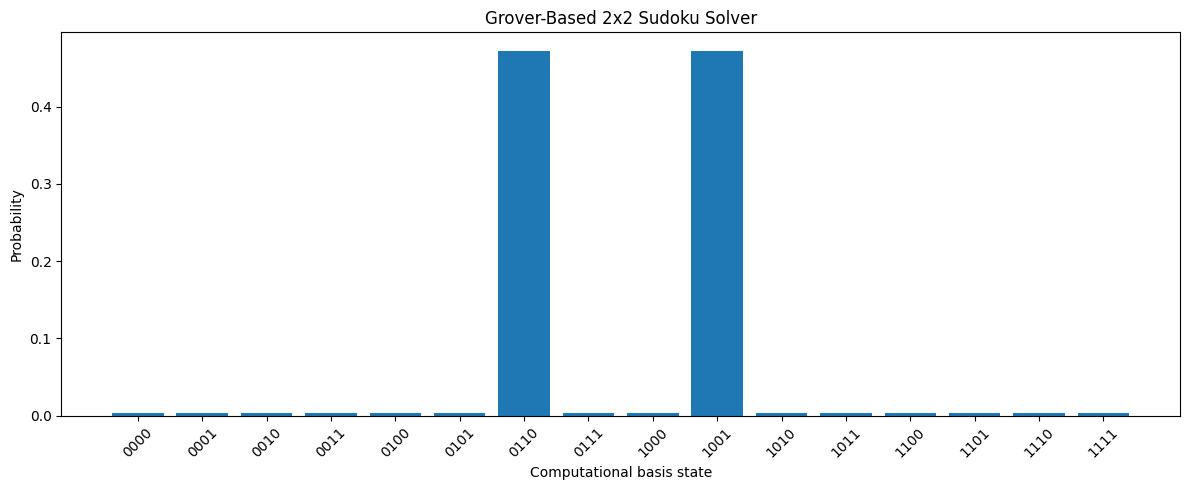


Circuit:



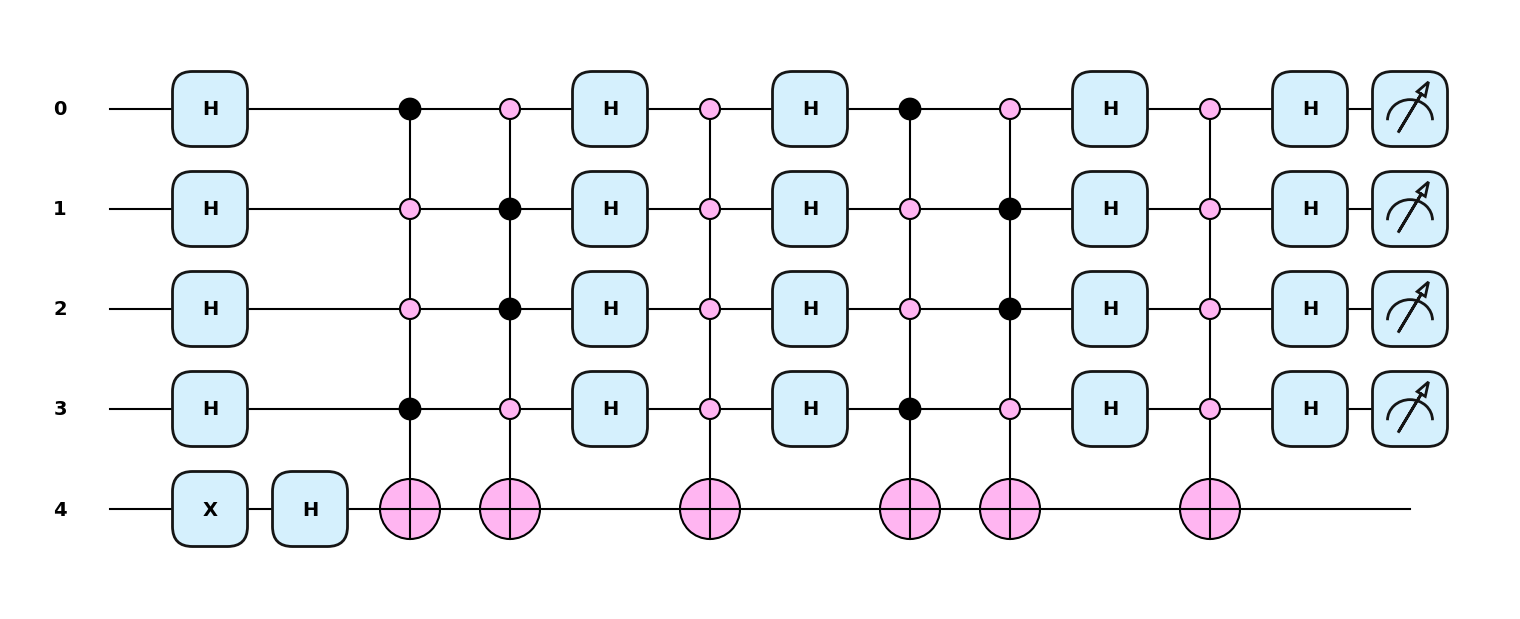

In [ ]:
query_wires = [0, 1, 2, 3]
aux_wire = [4]
total_wires = query_wires + aux_wire


dev = qml.device("default.qubit",wires=total_wires)


def sudoku_oracle():

    sol_one = [1,0,0,1]
    sol_two = [0,1,1,0]

    qp.MultiControlledX(total_wires,control_values=sol_one)
    qp.MultiControlledX(total_wires,control_values=sol_two)



def diffusion(wires):

    for w in wires:
        qml.H(wires=w)

    for w in wires:
        qml.X(wires=w)

    qp.MultiControlledX(total_wires,control_values=[1]*len(wires))

    for w in wires:
        qml.X(wires=w)

    for w in wires:
        qml.H(wires=w)



grover_iter = 2


@qml.qnode(dev)
def grover_sudoku():


    for wire in query_wires:
        qml.H(wire)


    qml.X(aux_wire)
    qml.H(aux_wire)


    for _ in range(grover_iter):

        sudoku_oracle()

        diffuser(query_wires)


    return qml.probs(wires=query_wires)


probs = grover_sudoku()



labels = [format(i, "04b") for i in range(16)]

plt.figure(figsize=(12, 5))

plt.bar(labels, probs)

plt.xlabel("Computational basis state")
plt.ylabel("Probability")
plt.title("Grover-Based 2x2 Sudoku Solver")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


print("\nCircuit:\n")

fig, ax = qp.draw_mpl(grover_sudoku, style='pennylane')()
fig.show()